# Task 5: Applying GraphSHAP-IQ to a new dataset

This notebook applies **GraphSHAP-IQ** to **IMDB-BINARY** from TU Dataset, a graph classification dataset that was **not** used in the original GraphSHAP-IQ paper experiments.

**Notebook structure:**
1. Load and preprocess the dataset
2. Exploratory data analysis (features, graph structure)
3. Define three GNN architectures
4. Train models (multi-seed)
5. Compute GraphSHAP-IQ explanations
6. Visualize and analyze interaction patterns

## 0. Setup and imports

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

import torch
from torch.nn import Linear, Sequential, ReLU

import torch_geometric
from torch_geometric.datasets import TUDataset
from torch_geometric.transforms import OneHotDegree
from torch_geometric.loader import DataLoader
from torch_geometric.utils import degree
from torch_geometric.nn import GCNConv, GINConv, GATConv, global_mean_pool
from torch_geometric.utils import to_networkx

from shapiq.explainer import Explainer
from shapiq.plot import si_graph_plot

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Loading data

IMDB-BINARY comes from the [TU Dortmund graph benchmark collection](https://chrsmrrs.github.io/datasets/docs/datasets/). 
- Each graph repesents an **ego-network of actors**
- Nodes = performers
- edges indicate co-appearance in movies
- Task is **binary graph classification** (two movie-genre groups (romance or action)).

The original dataset does not provide node features. Therefore, we use the node degree as a structural feature and encode it as a one-hot vector (OneHotDegree). This allows the GNN models to distinguish nodes based on their local connectivity patterns. This is a standard baseline feature representation for this dataset.

In [2]:
# Load raw dataset
raw_dataset = TUDataset(root="data/IMDB-BINARY", name="IMDB-BINARY")

# Degree means the number of neighbors a node has. We need to know the maximum degree to create one-hot encoded features of the right size.
max_degree = max(
    int(degree(g.edge_index[0], num_nodes=g.num_nodes).max())
    for g in raw_dataset
)

# Create one-hot degree features
dataset = TUDataset(
    root="data/IMDB-BINARY",
    name="IMDB-BINARY",
    pre_transform=OneHotDegree(max_degree=max_degree),
    force_reload=True,
)

in_channels = dataset.num_node_features
labels = np.array([g.y.item() for g in dataset])

# Dataset overview
classes, counts = np.unique(labels, return_counts=True)
class_info = ", ".join(
    [f"{c}: {int(n)} ({n/len(labels)*100:.1f}%)" for c, n in zip(classes, counts)]
)

overview_df = pd.DataFrame({
    "Metric": [
        "Number of graphs",
        "Number of classes",
        "Class distribution",
        "Maximum node degree",
        "Input feature dimension"
    ],
    "Value": [
        len(dataset),
        dataset.num_classes,
        class_info,
        max_degree,
        in_channels
    ]
})

overview_df

Processing...
Done!
Processing...
Done!


,Metric,Value
0,Number of graphs,1000
1,Number of classes,2
2,Class distribution,"0: 500 (50.0%), 1: 500 (50.0%)"
3,Maximum node degree,135
4,Input feature dimension,136


## 2. Class-wise example graph visualization (Data understanding)
To better understand the structural differences between the two classes in IMDB-BINARY, we visualize a small set of representative graphs from each class.

For each class, we select a few example graphs with relatively small node counts to ensure readability. Each graph is visualized as an ego-network where nodes represent actors and edges indicate co-appearances in movies.

Node size and color encode the node degree, highlighting highly connected actors within each graph. This helps to visually inspect structural patterns that may be relevant for the downstream classification task.

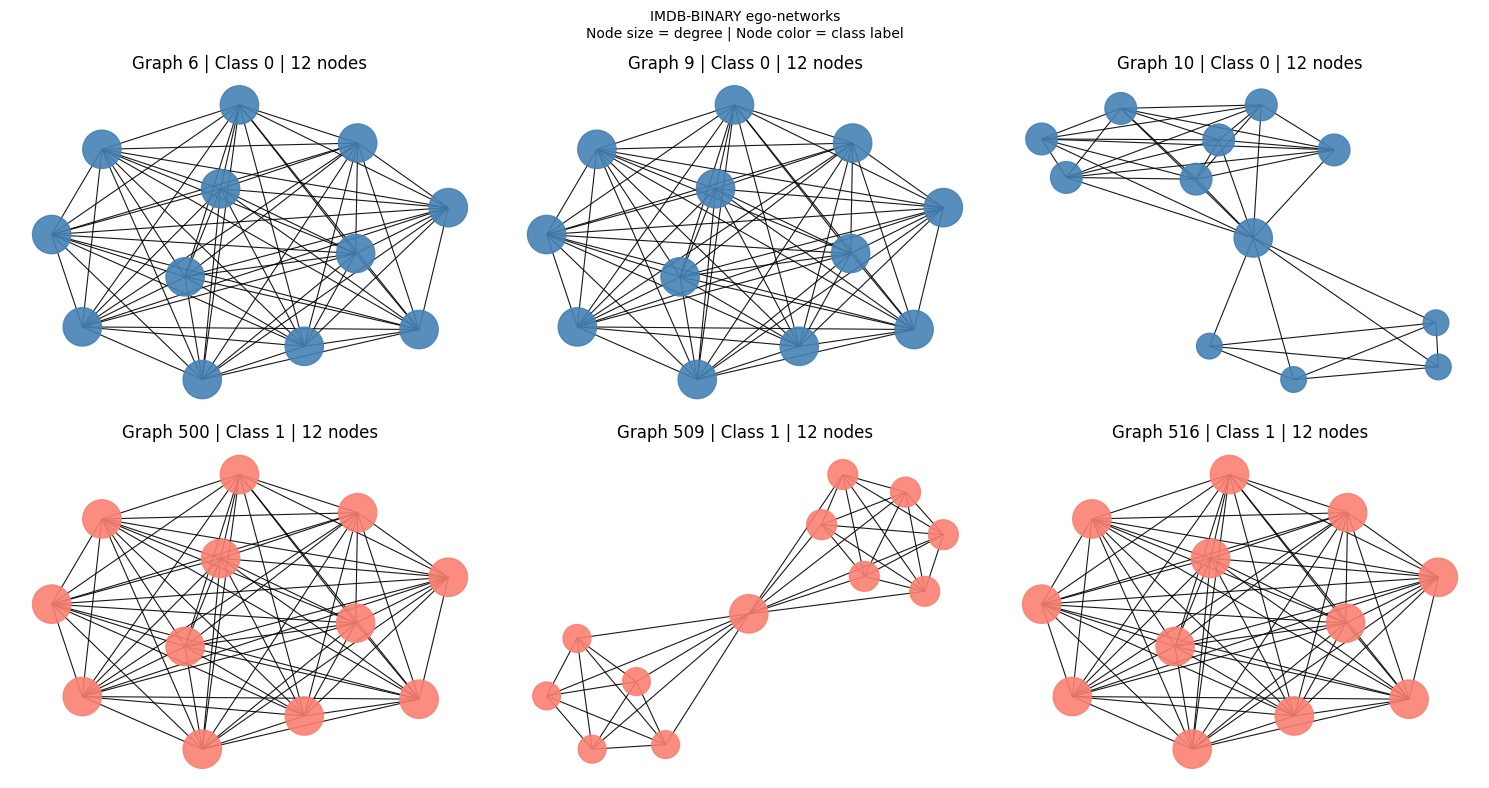

In [3]:
# =========================
# Select representative graphs per class
# =========================

example_indices = []

for c in np.unique(labels):

    # Get all graphs of class c
    class_indices = np.where(labels == c)[0]

    # Sort by graph size (optional but improves readability)
    class_indices = sorted(
        class_indices,
        key=lambda idx: dataset[int(idx)].num_nodes
    )

    # Take 3 representative graphs per class
    example_indices.extend(class_indices[:3])


# =========================
# Plot setup
# =========================

n_cols = 3
n_rows = int(np.ceil(len(example_indices) / n_cols))

CLASS_NAMES = {0: "Class 0", 1: "Class 1"}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)


# =========================
# Visualization
# =========================

for i, graph_idx in enumerate(example_indices):

    # Load graph
    g = dataset[int(graph_idx)]
    g_nx = to_networkx(g, to_undirected=True)

    # Layout
    pos = nx.spring_layout(g_nx, seed=SEED)

    # Node degrees (used for size)
    node_degrees = torch_geometric.utils.degree(
        g.edge_index[0],
        num_nodes=g.num_nodes
    ).numpy()

    # Node color = class label
    node_color = (
        "steelblue" if g.y.item() == 0 else "salmon"
    )

    # Draw graph
    nx.draw_networkx(
        g_nx,
        pos=pos,
        ax=axes[i],

        # structure → size
        node_size=100 + 60 * node_degrees,

        # class → color
        node_color=node_color,

        with_labels=False,
        width=0.8,
        alpha=0.9,
    )

    # Title
    axes[i].set_title(
        f"Graph {int(graph_idx)} | {CLASS_NAMES[int(g.y.item())]} | "
        f"{g.num_nodes} nodes"
    )
    axes[i].axis("off")


# =========================
# Remove empty axes
# =========================

for j in range(i + 1, len(axes)):
    axes[j].axis("off")


# =========================
# Global title
# =========================

plt.suptitle(
    "IMDB-BINARY ego-networks\n"
    "Node size = degree | Node color = class label",
    fontsize=10,
)

plt.tight_layout()
plt.show()

## 3. Train / validation / test split

We use a reproducible 70/10/20 split with a fixed random seed.

Since IMDB-BINARY does not provide a predefined split, this random partitioning is a standard evaluation protocol in graph classification benchmarks. The validation set is used for model selection and early stopping, ensuring a fair comparison across different GNN architectures.

In [4]:
from torch.utils.data import random_split

# =========================
# Reproducibility
# =========================

set_seed(SEED)

# Total number of graphs
n_total = len(dataset)

# =========================
# Split sizes (70 / 10 / 20)
# =========================

train_size = int(0.7 * n_total)
val_size = int(0.1 * n_total)
test_size = n_total - train_size - val_size  # ensures no rounding loss

# =========================
# Proper random split (PyTorch standard)
# =========================

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True   # important: stochasticity for training
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False  # deterministic evaluation
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False  # final evaluation must be stable
)

pd.DataFrame({
    "split": ["train", "val", "test"],
    "num_graphs": [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset)
    ]
})

,split,num_graphs
0,train,700
1,val,100
2,test,200


## 4. Define GNN architectures (GCN, GIN, GAT)

We use three standard message-passing architectures with three layers each and global mean pooling for graph-level readout. All models share the same hidden dimension (64) and output dimension (number of classes).


In [5]:
class GCNModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index, edge_weight=None).relu()
        x = self.conv2(x, edge_index, edge_weight=None).relu()
        x = self.conv3(x, edge_index, edge_weight=None).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)


class GINModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        nn1 = Sequential(Linear(in_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv1 = GINConv(nn1)
        nn2 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv2 = GINConv(nn2)
        nn3 = Sequential(Linear(hidden_channels, hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels))
        self.conv3 = GINConv(nn3)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)


class GATModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=2):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels // heads, heads=heads)
        self.conv2 = GATConv(hidden_channels, hidden_channels // heads, heads=heads)
        self.conv3 = GATConv(hidden_channels, hidden_channels // heads, heads=heads)
        self.lin = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index, edge_attr=None).relu()
        x = self.conv2(x, edge_index, edge_attr=None).relu()
        x = self.conv3(x, edge_index, edge_attr=None).relu()
        x = global_mean_pool(x, batch)
        return self.lin(x)

## 5. Train and evaluate models

Each architecture is trained on the 80% training split. We repeat training with multiple random seeds to get a rough stability estimate, then keep the last seed's model for explanation analysis.

In [6]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def test(model, loader):
    model.eval()
    correct = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=-1)
        correct += int((pred == data.y).sum())
    return correct / len(loader.dataset)


def run_experiment(model_class, epochs=35, lr=0.005, log_every=5):
    model = model_class(
        in_channels=in_channels,
        hidden_channels=64,
        out_channels=dataset.num_classes,
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    model_name = model_class.__name__
    print(f"\n{'='*55}", flush=True)
    print(f"  {model_name} | epochs={epochs} | lr={lr}", flush=True)
    print(f"{'='*55}", flush=True)
    print(f"{'Epoch':>6} | {'Loss':>8} | {'Train Acc':>10} | {'Test Acc':>9} | {'Best':>8}", flush=True)
    print(f"{'-'*55}", flush=True)

    best_test_acc = 0.0
    for epoch in range(1, epochs + 1):
        loss = train(model, train_loader, optimizer, criterion)
        train_acc = test(model, train_loader)
        test_acc = test(model, test_loader)
        best_test_acc = max(best_test_acc, test_acc)

        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            print(
                f"{epoch:>6} | {loss:>8.4f} | {train_acc:>10.4f} | "
                f"{test_acc:>9.4f} | {best_test_acc:>8.4f}",
                flush=True,
            )

    print(f"\n→ {model_name} abgeschlossen | Best Test Acc: {best_test_acc:.4f}\n", flush=True)
    return model, best_test_acc


# --- Multi-Seed Training ---
seeds = [42, 123, 999]
results = {'GCN': [], 'GIN': [], 'GAT': []}
trained_models = {}

print("Starting multi-seed training...", flush=True)
for model_name, model_cls in [('GCN', GCNModel), ('GIN', GINModel), ('GAT', GATModel)]:
    for seed in seeds:
        print(f"\n--- {model_name} | Seed {seed} ---", flush=True)
        set_seed(seed)
        model, acc = run_experiment(model_cls)
        results[model_name].append(acc)
        trained_models[model_name] = model

Starting multi-seed training...

--- GCN | Seed 42 ---

  GCNModel | epochs=35 | lr=0.005
 Epoch |     Loss |  Train Acc |  Test Acc |     Best
-------------------------------------------------------
     1 |   0.6585 |     0.6986 |    0.7900 |   0.7900
     5 |   0.5221 |     0.7286 |    0.7600 |   0.8000
    10 |   0.5044 |     0.7286 |    0.7550 |   0.8000
    15 |   0.4990 |     0.7457 |    0.7550 |   0.8000
    20 |   0.4902 |     0.7400 |    0.7450 |   0.8200
    25 |   0.4663 |     0.7614 |    0.8100 |   0.8250
    30 |   0.4552 |     0.7571 |    0.7450 |   0.8250
    35 |   0.4577 |     0.7543 |    0.7400 |   0.8250

→ GCNModel abgeschlossen | Best Test Acc: 0.8250


--- GCN | Seed 123 ---

  GCNModel | epochs=35 | lr=0.005
 Epoch |     Loss |  Train Acc |  Test Acc |     Best
-------------------------------------------------------
     1 |   0.6572 |     0.7057 |    0.7950 |   0.7950
     5 |   0.5261 |     0.7314 |    0.7750 |   0.7950
    10 |   0.5157 |     0.7343 |    0.78